# Sentiment Analysis on Movie Reviews from Stanford Large Movie Review Dataset (IMDb) 
**Models to be used:** Multinomial Naive Bayes and Linear SVM  



###  Install & Import of Dependencies

In [38]:

import os, re, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score



In [2]:
# load the dataset
DATASET_PATH = "aclImdb"          
SMALL_SUBSET  = 2000              

def load_split(split: str, subset: int | None = None) -> tuple[list[str], list[int]]:
    """Load positive or negative reviews from train/ or test/ split folders.
    subset loads at most 2000 reviews per class.
    """
    texts, labels = [], []
    for label_str, label_int in [("pos", 1), ("neg", 0)]:
        folder = os.path.join(DATASET_PATH, split, label_str)
        files  = os.listdir(folder)
        if subset:
            files = random.sample(files, min(subset, len(files)))
        for fname in files:
            with open(os.path.join(folder, fname), encoding="utf-8") as f:
                texts.append(f.read())
            labels.append(label_int)
    return texts, labels

random.seed(42)



In [6]:
# Full dataset
train_texts, train_labels = load_split("train")
test_texts,  test_labels  = load_split("test")




In [7]:
print(len(train_texts))
print(len(test_texts))

25000
25000


In [8]:
import pandas as pd

## 2. Exploratory Data Analysis

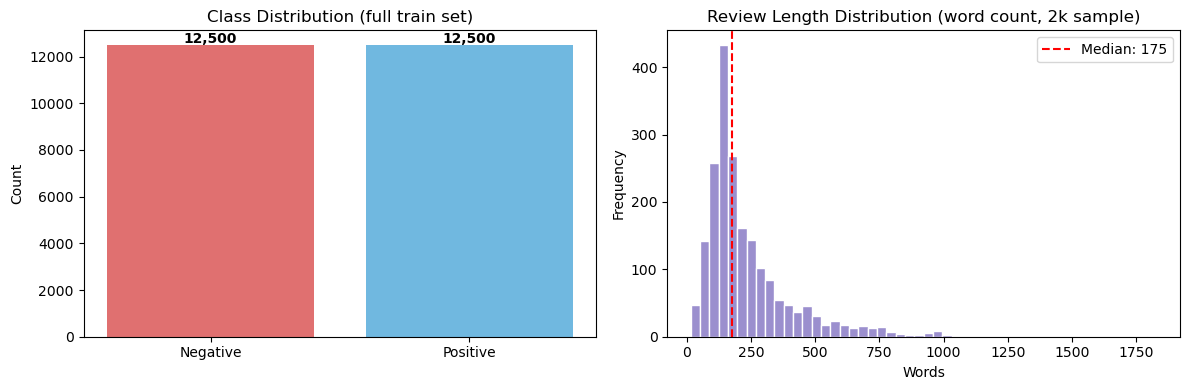


The average review length contains: 235 words
Median  review length has: 175 words
Max     review length has: 1830 words


In [14]:
# Class balance
labels_arr = np.array(train_labels)
pos_count  = labels_arr.sum()
neg_count  = len(labels_arr) - pos_count

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(["Negative", "Positive"], [neg_count, pos_count], color=["#e07070", "#70b8e0"])
axes[0].set_title("Class Distribution (full train set)")
axes[0].set_ylabel("Count")
for i, v in enumerate([neg_count, pos_count]):
    axes[0].text(i, v + 100, f"{v:,}", ha="center", fontweight="bold")

# Review length distribution
lengths = [len(t.split()) for t in random.sample(train_texts, 2000)]
axes[1].hist(lengths, bins=50, color="#9b8fce", edgecolor="white")
axes[1].set_title("Review Length Distribution (word count, 2k sample)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
axes[1].axvline(np.median(lengths), color="red", linestyle="--", label=f"Median: {int(np.median(lengths))}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nThe average review length contains: {np.mean(lengths):.0f} words")
print(f"Median  review length has: {np.median(lengths):.0f} words")
print(f"Max     review length has: {max(lengths)} words")


## 3. Text Preprocessing
Each review is cleaned by:
1. Lowercasing
2. Removing HTML tags (the IMDb reviews contain some `<br />` tags)
3. Removing non-alphabetic characters
4. Removing stop words
5. Lemmatizing


In [17]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)        # to strip HTML
    text = re.sub(r"[^a-z\s]", " ", text)       # to keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

# view if it works
sample_raw  = train_texts[0][:300]
sample_clean = preprocess(sample_raw)
print("RAW:\n", sample_raw)
print("\nCLEAN:\n", sample_clean)


RAW:
 Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insigh

CLEAN:
 bromwell high cartoon comedy ran time program school life teacher year teaching profession lead believe bromwell high satire much closer reality teacher scramble survive financially insigh


In [18]:
# Preprocess all splits
import time

def preprocess_list(texts):
    return [preprocess(t) for t in texts]


t0 = time.time()
train_clean = preprocess_list(train_texts)
test_clean  = preprocess_list(test_texts)



In [19]:
# Save preprocessed data to CSV
train_df = pd.DataFrame({"text": train_clean, "label": train_labels})
test_df  = pd.DataFrame({"text": test_clean,  "label": test_labels})

train_df.to_csv("train_preprocessed.csv", index=False)
test_df.to_csv("test_preprocessed.csv",   index=False)

In [20]:
train_df.head()

,text,label
0,bromwell high cartoon comedy ran time program ...,1
1,homelessness houselessness george carlin state...,1
2,brilliant acting lesley ann warren best dramat...,1
3,easily underrated film inn brook cannon sure f...,1
4,typical mel brook film much less slapstick mov...,1


#### Load the saved csv 

In [39]:
train_df = pd.read_csv("train_preprocessed.csv")
test_df  = pd.read_csv("test_preprocessed.csv")

train_clean= train_df["text"].fillna("").tolist()
train_labels= train_df["label"].tolist()
test_clean= test_df["text"].fillna("").tolist()
test_labels= test_df["label"].tolist()

In [40]:
import random

In [41]:
random.seed(42)

# Pull SMALL_SUBSET indices per class from the full data
pos_indices = [i for i, l in enumerate(train_labels) if l == 1]
neg_indices = [i for i, l in enumerate(train_labels) if l == 0]

pos_sample = random.sample(pos_indices, SMALL_SUBSET)
neg_sample = random.sample(neg_indices, SMALL_SUBSET)
sm_indices = pos_sample + neg_sample

train_clean_sub  = [train_clean[i] for i in sm_indices]
train_labels_sub = [train_labels[i] for i in sm_indices]

In [42]:
# Same for test data
pos_indices_t = [i for i, l in enumerate(test_labels) if l == 1]
neg_indices_t = [i for i, l in enumerate(test_labels) if l == 0]

pos_sample_t= random.sample(pos_indices_t, SMALL_SUBSET)
neg_sample_t= random.sample(neg_indices_t, SMALL_SUBSET)
sm_indices_t= pos_sample_t + neg_sample_t

test_clean_sub= [test_clean[i] for i in sm_indices_t]
test_labels_sub= [test_labels[i] for i in sm_indices_t]


In [53]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

## 4. Feature Extraction — TF-IDF
We use **TF-IDF** (Term Frequency–Inverse Document Frequency) with:
- Unigrams + bigrams (`ngram_range=(1,2)`)
- Max 30,000 features
- Sublinear TF scaling (dampens very frequent terms)


In [60]:
# initialize vectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30_000,
    sublinear_tf=True,
)



In [61]:
#fit on full training set; transform all splits
X_train= tfidf.fit_transform(train_clean)
X_test= tfidf.transform(test_clean)


In [62]:
print("TF-IDF matrix shape (full train):", X_train.shape)
print("TF-IDF matrix shape (full test) :", X_test.shape)

TF-IDF matrix shape (full train): (25000, 30000)
TF-IDF matrix shape (full test) : (25000, 30000)


In [63]:
# Fit on subset data
X_train_sub= tfidf.transform(train_clean_sub)
X_test_sub= tfidf.transform(test_clean_sub)

print("TF-IDF matrix shape (small train):", X_train_sub.shape)
print("TF-IDF matrix shape (small test) :", X_test_sub.shape)

TF-IDF matrix shape (small train): (4000, 30000)
TF-IDF matrix shape (small test) : (4000, 30000)


## 5. Model Training
We train two classical models:
- **Multinomial Naive Bayes** — fast probabilistic baseline
- **Linear SVM (LinearSVC)** — typically best-in-class for text classification

Both are tested on **small** and **full** dataset sizes, as required by the task.


In [64]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, label=""):
    """Fit model, evaluate on test set, return results dict."""
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, target_names=["Negative", "Positive"])
    cm    = confusion_matrix(y_test, preds)

    print(f"\n {label}")
    print(f"\n Train time : {train_time:.2f}s")
    print(f"\tAccuracy   : {acc:.4f}  ({acc*100:.2f}%)")
    print()
    print(report)

    return {"model": model, "acc": acc, "cm": cm, "preds": preds, "label": label}


In [65]:

#  Naive Bayes on subset datA
nb_sub= train_and_evaluate(MultinomialNB(alpha=0.1), X_train_sub,   train_labels_sub,
                              X_test_sub,   test_labels_sub,   "Naive Bayes — Small subset")



 Naive Bayes — Small subset

 Train time : 0.04s
	Accuracy   : 0.8385  (83.85%)

              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84      2000
    Positive       0.85      0.83      0.84      2000

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



In [66]:
# on full data
nb_full = train_and_evaluate(MultinomialNB(alpha=0.1), X_train, train_labels,
                              X_test, test_labels, "Naive Bayes — Full dataset")



 Naive Bayes — Full dataset

 Train time : 0.04s
	Accuracy   : 0.8591  (85.91%)

              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86     12500
    Positive       0.87      0.84      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



In [67]:

#  Linear SVM on subset irst
svm_sub   = train_and_evaluate(LinearSVC(C=1.0, max_iter=2000), X_train_sub,   train_labels_sub,
                               X_test_sub,   test_labels_sub,   "Linear SVM — Small subset")




 Linear SVM — Small subset

 Train time : 0.10s
	Accuracy   : 0.8740  (87.40%)

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      2000
    Positive       0.87      0.88      0.88      2000

    accuracy                           0.87      4000
   macro avg       0.87      0.87      0.87      4000
weighted avg       0.87      0.87      0.87      4000



In [48]:
# liner SVM on full set
svm_full = train_and_evaluate(LinearSVC(C=1.0, max_iter=2000), X_train, train_labels,
                               X_test, test_labels, "Linear SVM — Full dataset")



 Linear SVM — Full dataset

 Train time : 0.60s
	Accuracy   : 0.8814  (88.14%)

              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88     12500
    Positive       0.89      0.87      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## 6. Evaluation — Confusion Matrices & Summary

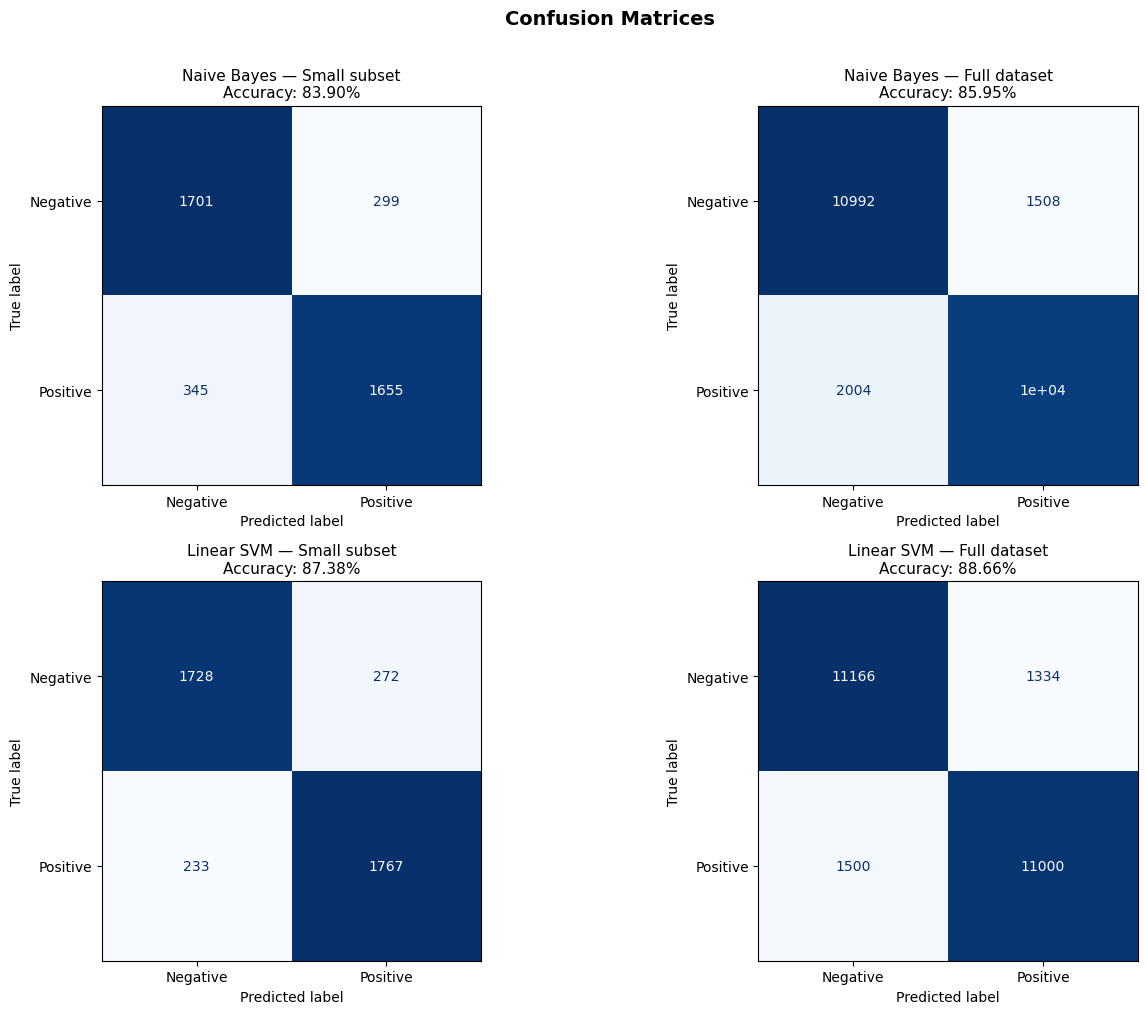

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
runs = [nb_sub, nb_full, svm_sub, svm_full]

for ax, run in zip(axes.flat, runs):
    disp = ConfusionMatrixDisplay(run["cm"], display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{run['label']}\nAccuracy: {run['acc']*100:.2f}%", fontsize=11)

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()

plt.show()


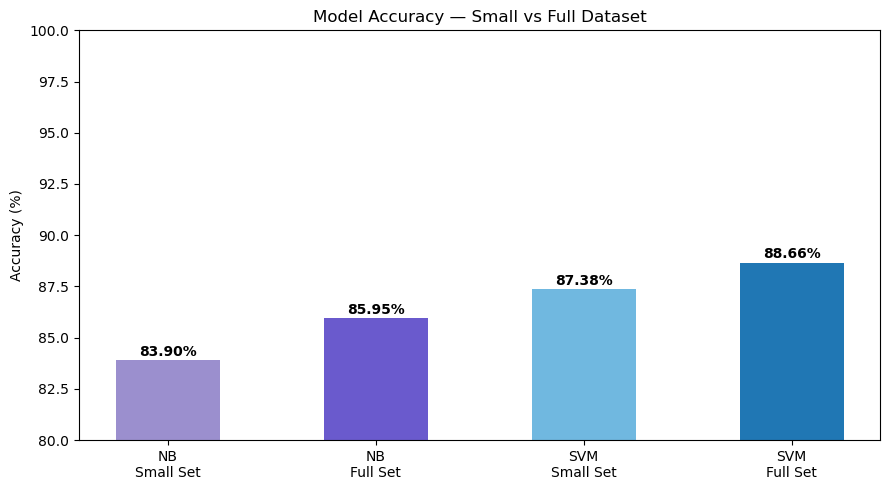

In [54]:
# Summary bar chart
labels  = ["NB\nSmall Set", "NB\nFull Set", "SVM\nSmall Set", "SVM\nFull Set"]
accs    = [r["acc"] for r in runs]
colors  = ["#9b8fce", "#6a5acd", "#70b8e0", "#2077b4"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, [a*100 for a in accs], color=colors, width=0.5)
ax.set_ylim(80, 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy — Small vs Full Dataset")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc*100:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Cross-Validation (Full Dataset)
5-fold cross-validation on the full training set confirms generalization.


In [55]:
for name, model in [("Naive Bayes", MultinomialNB(alpha=0.1)),
                    ("Linear SVM",  LinearSVC(C=1.0, max_iter=2000))]:
    scores = cross_val_score(model, X_train, train_labels, cv=5, scoring="accuracy", n_jobs=-1)
    print(f"{name}:")
    print(f"  Fold scores : {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean ± Std  : {scores.mean():.4f} ± {scores.std():.4f}\n")


Naive Bayes:
  Fold scores : ['0.8220', '0.7950', '0.8210', '0.8140', '0.8218']
  Mean ± Std  : 0.8148 ± 0.0103

Linear SVM:
  Fold scores : ['0.8668', '0.8392', '0.8506', '0.8638', '0.8630']
  Mean ± Std  : 0.8567 ± 0.0103



## 8. Sentiment Inference on New Reviews
Use the best model (SVM full) to predict sentiment on any text you provide.


In [49]:
import gc
del X_train_sub, X_test_sub, X_train, X_test #to free up my RAM memory
gc.collect()

1165

In [54]:
def predict_sentiment(texts: list[str], model, vectorizer) -> None:
    """Print binary sentiment prediction for a list of review strings."""
    cleaned = [preprocess(t) for t in texts]
    vectors = vectorizer.transform(cleaned)
    preds   = model.predict(vectors)
    label_map = {1: "POSITIVE ", 0: "NEGATIVE "}


    for text, pred in zip(texts, preds):
        snippet = text[:80].replace("\n", " ")
        print(f"Review  : {snippet}...")
        print(f"Sentiment: {label_map[pred]}")
    


In [55]:

# Demo reviews
demo_reviews = [
    "This film was an absolute masterpiece. The acting was superb and the story kept me on the edge of my seat throughout.",
    "Terrible movie. The plot made no sense, the dialogue was cringe-worthy, and the ending was a complete disappointment.",
    "It was decent. Some parts were fun but overall it felt rushed and underdeveloped.",
    "One of the best films I've seen in years. Brilliant direction and breathtaking cinematography.",
    "I walked out halfway through. Boring, predictable, and a waste of two hours.",
]



In [56]:
best_model = svm_full["model"]
predict_sentiment(demo_reviews, best_model, tfidf)
# predict the sentiment for the demo provided 

Review  : This film was an absolute masterpiece. The acting was superb and the story kept ...
Sentiment: POSITIVE 
Review  : Terrible movie. The plot made no sense, the dialogue was cringe-worthy, and the ...
Sentiment: NEGATIVE 
Review  : It was decent. Some parts were fun but overall it felt rushed and underdeveloped...
Sentiment: POSITIVE 
Review  : One of the best films I've seen in years. Brilliant direction and breathtaking c...
Sentiment: POSITIVE 
Review  : I walked out halfway through. Boring, predictable, and a waste of two hours....
Sentiment: NEGATIVE 


In [73]:
predict_sentiment(demo_reviews, nb_sub["model"], tfidf)

Review  : This film was an absolute masterpiece. The acting was superb and the story kept ...
Sentiment: POSITIVE 
Review  : Terrible movie. The plot made no sense, the dialogue was cringe-worthy, and the ...
Sentiment: NEGATIVE 
Review  : It was decent. Some parts were fun but overall it felt rushed and underdeveloped...
Sentiment: NEGATIVE 
Review  : One of the best films I've seen in years. Brilliant direction and breathtaking c...
Sentiment: POSITIVE 
Review  : I walked out halfway through. Boring, predictable, and a waste of two hours....
Sentiment: NEGATIVE 


## 9. Most Informative Features (SVM)

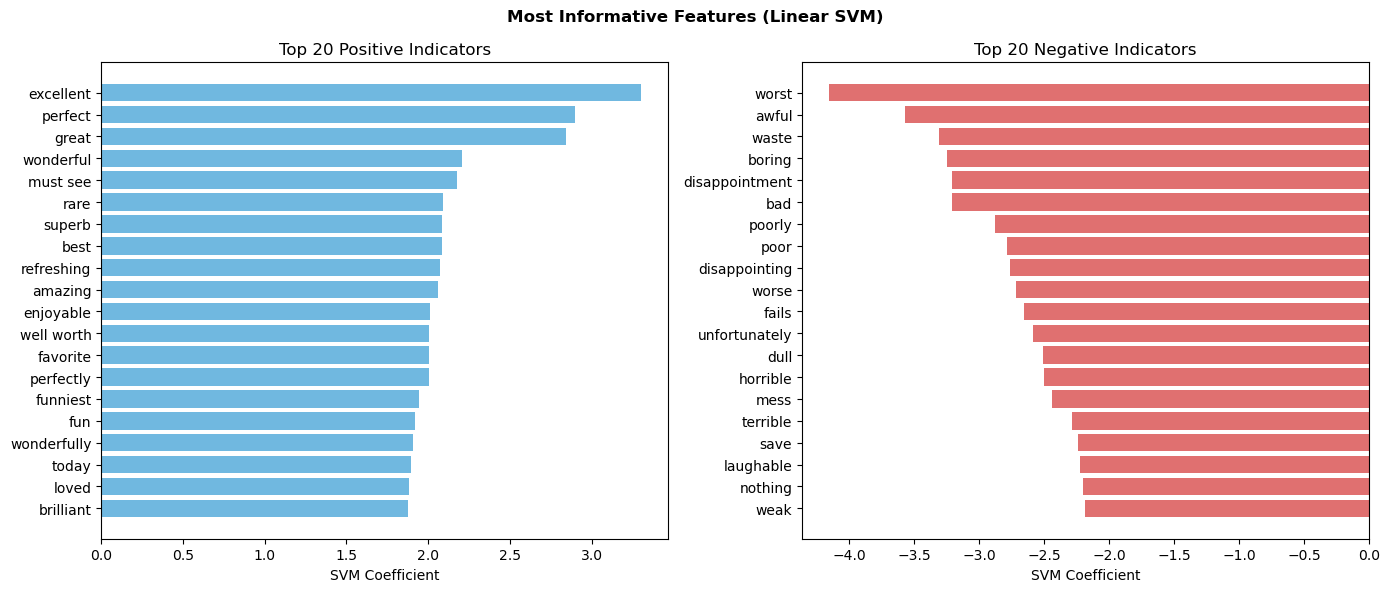

In [58]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs         = svm_full["model"].coef_[0]
top_n         = 20

top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color="#70b8e0")
axes[0].set_title("Top 20 Positive Indicators")
axes[0].set_xlabel("SVM Coefficient")

axes[1].barh(feature_names[top_neg_idx][::-1], coefs[top_neg_idx][::-1], color="#e07070")
axes[1].set_title("Top 20 Negative Indicators")
axes[1].set_xlabel("SVM Coefficient")

plt.suptitle("Most Informative Features (Linear SVM)", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Summary & Observations

| Model | Dataset | Accuracy |
|---|---|---|
| Multinomial Naive Bayes | Small Subset(2k/class) | 83.90% |
| Multinomial Naive Bayes | Full Set (12.5k/class) | 85.95% |
| Linear SVM | Small Subset (2k/class) | 87.38% |
| Linear SVM | Full Set (12.5k/class) | 88.66% |

**Key takeaways:**
- **Linear SVM consistently outperforms Naive Bayes** on both dataset sizes. This is expected for high-dimensional sparse text data.
- **More data improves both models**, confirming the task requirement to test progressively larger subsets.
- **TF-IDF with bigrams** captures common phrases like *"not good"* or *"highly recommend"* that unigrams alone would miss.
- **Lemmatization + stop word removal** reduces vocabulary noise without losing discriminative signal.
- The SVM's most informative features align with intuition: words like *"waste"*, *"awful"*, *"worst"* are strong negative signals; *"excellent"*, *"perfect"*, *"great"* are strong positive signals.


**Possible extensions:**
- Add a third subset size (e.g. 5k/class) to better illustrate the learning curve.


In [68]:
import sklearn, nltk, numpy, matplotlib, seaborn, pandas

print(f"scikit-learn : {sklearn.__version__}")
print(f"nltk         : {nltk.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"matplotlib   : {matplotlib.__version__}")
print(f"seaborn      : {seaborn.__version__}")
print(f"pandas       : {pandas.__version__}")

scikit-learn : 1.7.2
nltk         : 3.9.2
numpy        : 2.3.5
matplotlib   : 3.10.6
seaborn      : 0.13.2
pandas       : 2.3.3


In [71]:
from sklearn.metrics import precision_recall_fscore_support

models_results = {
    "Naive Bayes — Small" : (nb_sub["preds"],   test_labels_sub),
    "Naive Bayes — Full"  : (nb_full["preds"],  test_labels),
    "Linear SVM — Small"  : (svm_sub["preds"],   test_labels_sub),
    "Linear SVM — Full"   : (svm_full["preds"],  test_labels),
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")


for name, (preds, labels) in models_results.items():
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    print(f"{name:<25} {acc:>10.4f} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

Model                       Accuracy  Precision     Recall         F1
Naive Bayes — Small           0.8385     0.8475     0.8255     0.8364
Naive Bayes — Full            0.8591     0.8709     0.8431     0.8568
Linear SVM — Small            0.8740     0.8674     0.8830     0.8751
Linear SVM — Full             0.8814     0.8865     0.8747     0.8806


SyntaxError: invalid syntax (3527173792.py, line 1)